Tesla Stock Analysis Results
Latest Closing Price: 328.5
50-Day Moving Average: 401.65700000000004
100-Day Moving Average: 335.0811
200-Day Moving Average: 269.66665
Below 50-Day MA: True
Below 100-Day MA: True
Below 200-Day MA: False


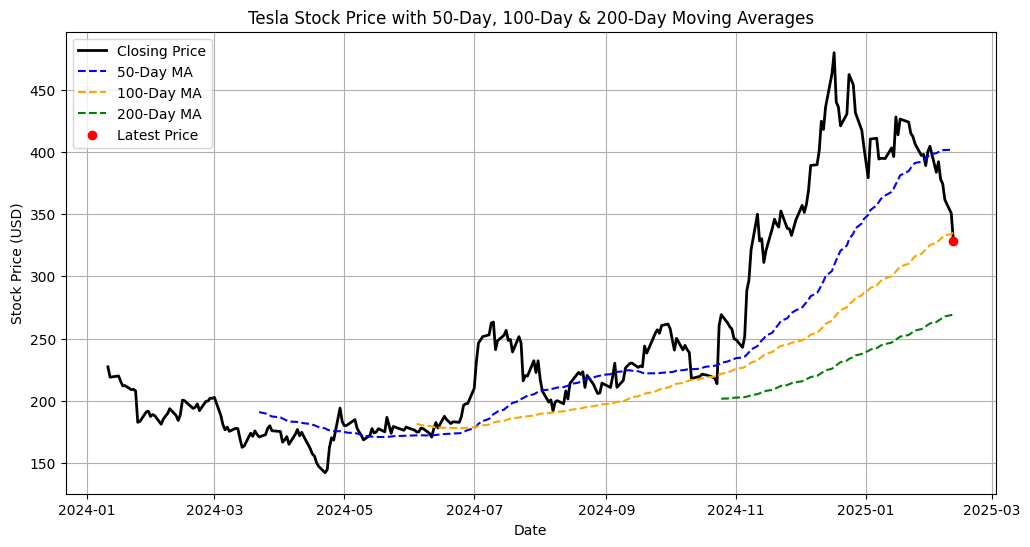

In [5]:

import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = "/tesla csv data.xlsx"  # Update with your file path
xls = pd.ExcelFile(file_path)

# Load the data from the first sheet
df = pd.read_excel(xls, sheet_name='Sheet1')

# Clean and preprocess the data
df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']  # Standardize column names
df['Date'] = pd.to_datetime(df['Date'])  # Convert Date to datetime format
df = df.sort_values(by='Date')  # Sort by date

# Calculate moving averages
df['50_Day_MA'] = df['Close'].rolling(window=50).mean()
df['100_Day_MA'] = df['Close'].rolling(window=100).mean()
df['200_Day_MA'] = df['Close'].rolling(window=200).mean()

# Get the latest available data
latest_data = df.iloc[-1]

# Check if the stock has fallen below key moving averages
below_50DMA = latest_data['Close'] < latest_data['50_Day_MA']
below_100DMA = latest_data['Close'] < latest_data['100_Day_MA']
below_200DMA = latest_data['Close'] < latest_data['200_Day_MA']

# Prepare the analysis results
analysis_results = {
    "Latest Closing Price": latest_data['Close'],
    "50-Day Moving Average": latest_data['50_Day_MA'],
    "100-Day Moving Average": latest_data['100_Day_MA'],
    "200-Day Moving Average": latest_data['200_Day_MA'],
    "Below 50-Day MA": below_50DMA,
    "Below 100-Day MA": below_100DMA,
    "Below 200-Day MA": below_200DMA
}

# Print analysis results
print("Tesla Stock Analysis Results")
for key, value in analysis_results.items():
    print(f"{key}: {value}")

# Plot Tesla's stock price with moving averages
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label="Closing Price", color='black', linewidth=2)
plt.plot(df['Date'], df['50_Day_MA'], label="50-Day MA", linestyle='dashed', color='blue', linewidth=1.5)
plt.plot(df['Date'], df['100_Day_MA'], label="100-Day MA", linestyle='dashed', color='orange', linewidth=1.5)
plt.plot(df['Date'], df['200_Day_MA'], label="200-Day MA", linestyle='dashed', color='green', linewidth=1.5)

# Highlight the latest closing price
plt.scatter(df['Date'].iloc[-1], df['Close'].iloc[-1], color='red', label="Latest Price", zorder=3)

# Labels and title
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.title("Tesla Stock Price with 50-Day, 100-Day & 200-Day Moving Averages")
plt.legend()
plt.grid()

# Show the chart
plt.show()
